# Statistics Foundations

## 1. Exploration (Exercises)

### 1.1 Abalone

The [Abalone](https://archive.ics.uci.edu/dataset/1/abalone) dataset contains measurements of over 4000 abalone (sea snails).

You can find the data in `data/abalone.csv`

Load the data into a `pandas` dataframe.

In [20]:
import pandas as pd

data = pd.read_csv("data/abalone.csv")

# print(data.head(10))

print(data.info())
print("*"*50)

print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Sex       4177 non-null   object 
 1   Rings     4177 non-null   int64  
 2   Length    4177 non-null   float64
 3   Diameter  4177 non-null   float64
 4   Height    4177 non-null   float64
 5   Weight    4177 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 195.9+ KB
None
**************************************************
             Rings       Length     Diameter       Height       Weight
count  4177.000000  4177.000000  4177.000000  4177.000000  4177.000000
mean      9.933684     0.523992     0.407881     0.139516     0.828742
std       3.224169     0.120093     0.099240     0.041827     0.490389
min       1.000000     0.075000     0.055000     0.000000     0.002000
25%       8.000000     0.450000     0.350000     0.115000     0.441500
50%       9.000000     0.545000     

What size is this sample?

In [2]:
sample_size = len(data)

print(f"Sample size = {sample_size}")

Sample size = 4177


Are there any missing values in the data?

In [3]:
missing_values = data.isnull().sum()

print(f"Missing values: ")
print(missing_values)

Missing values: 
Sex         0
Rings       0
Length      0
Diameter    0
Height      0
Weight      0
dtype: int64


Visualise the distribution of the `Weight` variable.

<Axes: xlabel='Weight', ylabel='Frequency'>

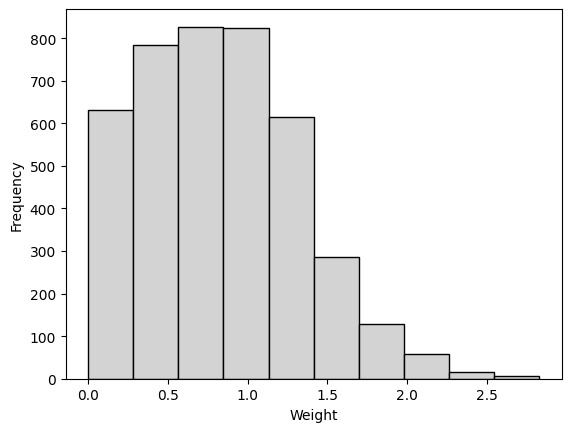

In [9]:

data["Weight"].plot.hist(xlabel='Weight',
               color='lightgrey',
               edgecolor='black')

Now make a visualisation to compare the distribution of `Weight` for the three values of `Sex` (M=male/F=female/I=infant).

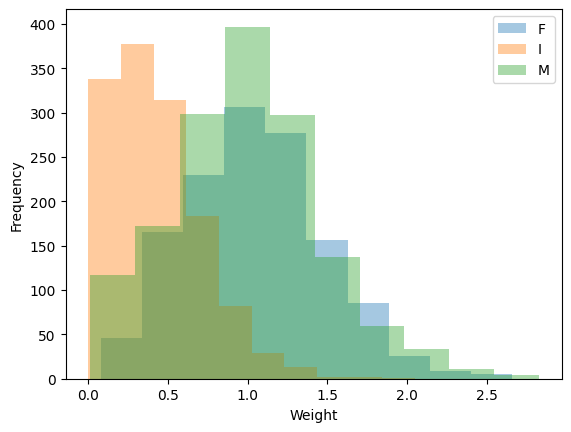

In [15]:
data.groupby('Sex')['Weight'] \
    .plot.hist(alpha=0.4, # controls the opacity of the bars
               xlabel='Weight',
               legend=True)
plt.show()

The variable `Rings` is closely related to the snail's age.

Use a bar chart to visualise the distribution of `Rings`.

<Axes: xlabel='Rings', ylabel='Frequency'>

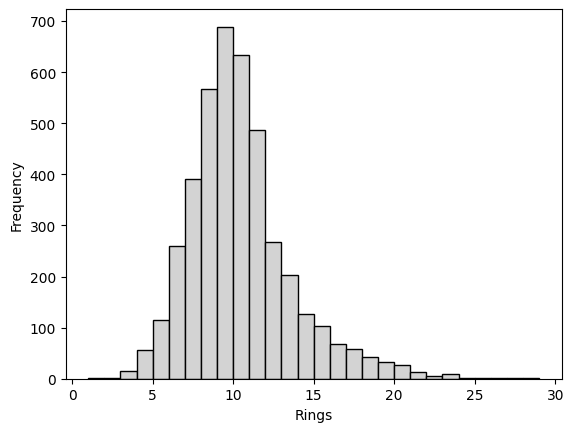

In [53]:

data["Rings"].plot.hist(xlabel='Rings',
               color='lightgrey',
               edgecolor='black',
               bins=len(pd.unique(data["Rings"])))

Now show how much of each bar is made up of each `Sex`.

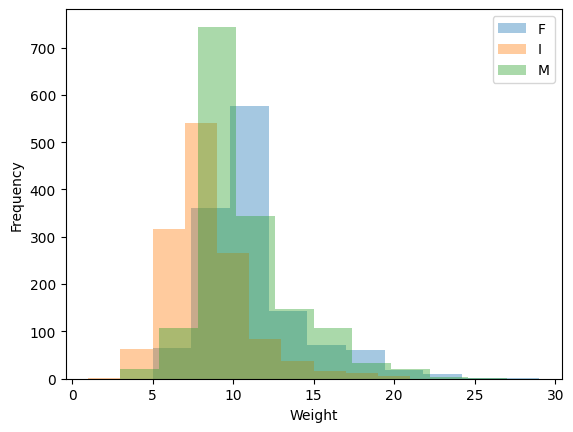

In [12]:
data.groupby('Sex')['Rings'] \
    .plot.hist(alpha=0.4, # controls the opacity of the bars
               xlabel='Weight',
               legend=True)
plt.show()

Visualise the relationship between `Length` and `Rings`.

<Axes: xlabel='Length', ylabel='Rings'>

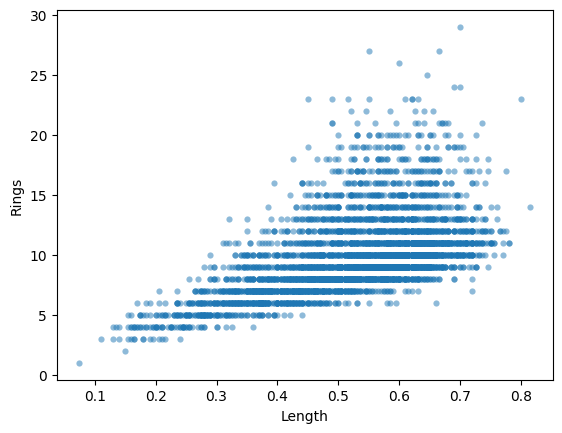

In [25]:
data.plot.scatter("Length", "Rings",
                  linewidth=0, 
                alpha=0.5)

### 1.2 MAGIC Gamma Telescope

The [MAGIC](https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope) dataset is a simulated dataset used to investigate the separation of high energy gamma rays from background signals in an atmospheric Cherenkov telescope.

The data can be found in `data/magic04.csv`.

Load the data into a `pandas` dataframe.

In [28]:
import pandas

magic = pd.read_csv("data/magic04.csv")

print(magic.info())
print("*"*10)
print(magic.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19020 entries, 0 to 19019
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Length   19020 non-null  float64
 1   Width    19020 non-null  float64
 2   Size     19020 non-null  float64
 3   Conc     19020 non-null  float64
 4   Conc1    19020 non-null  float64
 5   Asym     19020 non-null  float64
 6   M3Long   19020 non-null  float64
 7   M3Trans  19020 non-null  float64
 8   Alpha    19020 non-null  float64
 9   Dist     19020 non-null  float64
 10  class    19020 non-null  object 
dtypes: float64(10), object(1)
memory usage: 1.6+ MB
None
**********
             Length         Width          Size          Conc         Conc1  \
count  19020.000000  19020.000000  19020.000000  19020.000000  19020.000000   
mean      53.250154     22.180966      2.825017      0.380327      0.214657   
std       42.364855     18.346056      0.472599      0.182813      0.110511   
min        4

How is the distribution of `Alpha` different between signal and background?

*Hint*: in the `class` variable, `'g'` corresponds to a gamma ray (signal) and `'h'` corresponds to a hadron (background).

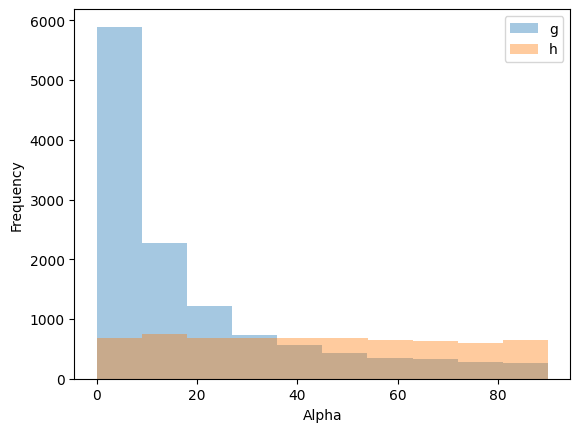

In [35]:
magic.groupby("class")["Alpha"].plot.hist(alpha=0.4, 
                                          legend=True,
                                          xlabel="Alpha")
plt.show()

Using a `for` loop, compare the signal/background distributions for each of the variables.

*Hint*: The column headers can be obtained using `DataFrame.columns`.

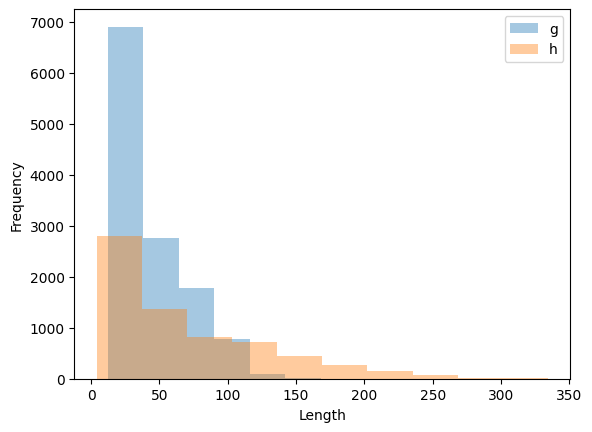

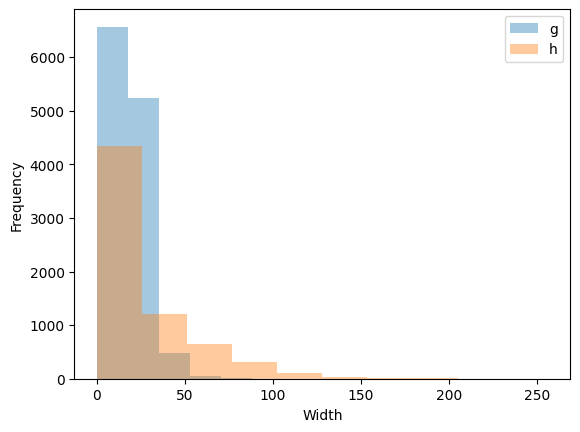

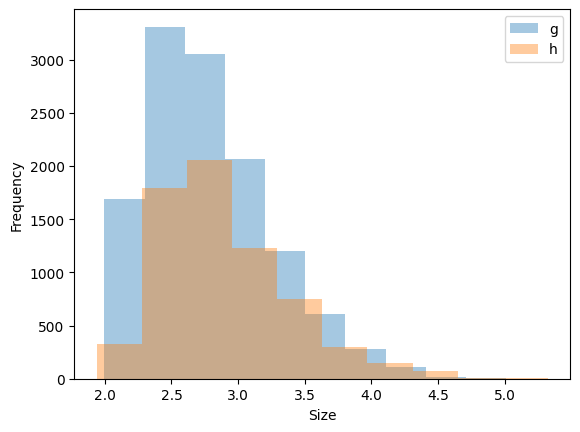

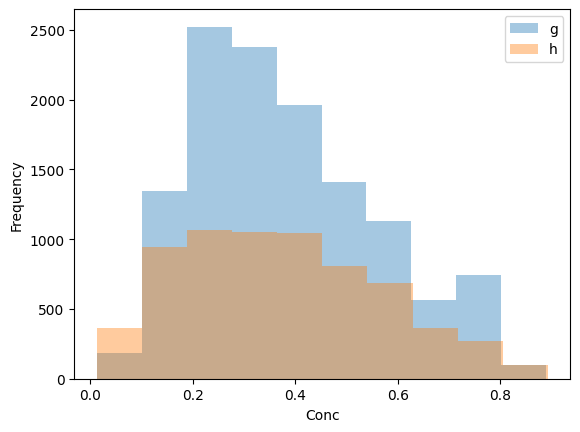

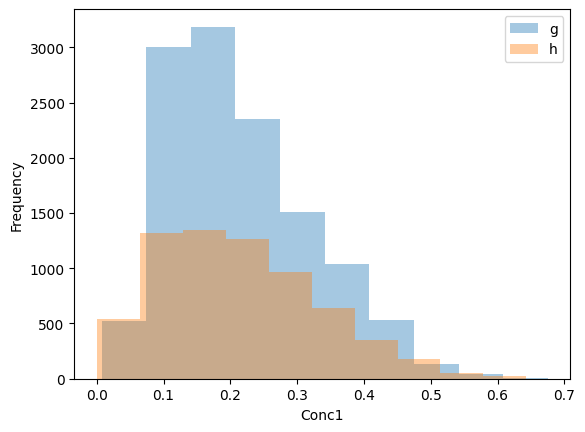

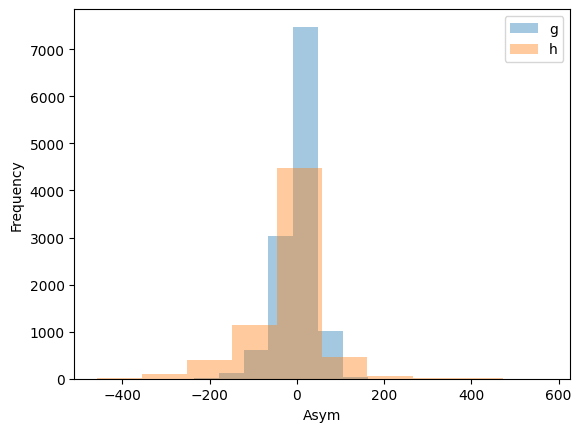

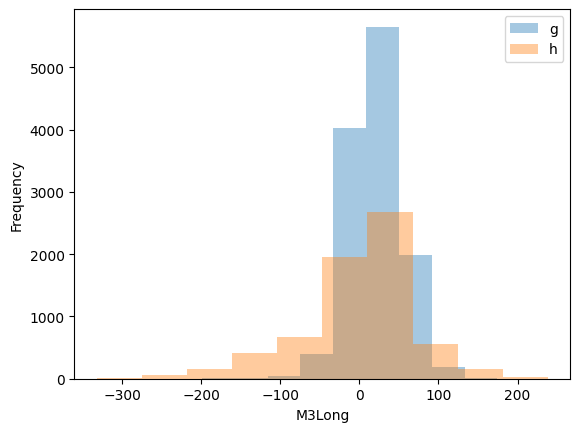

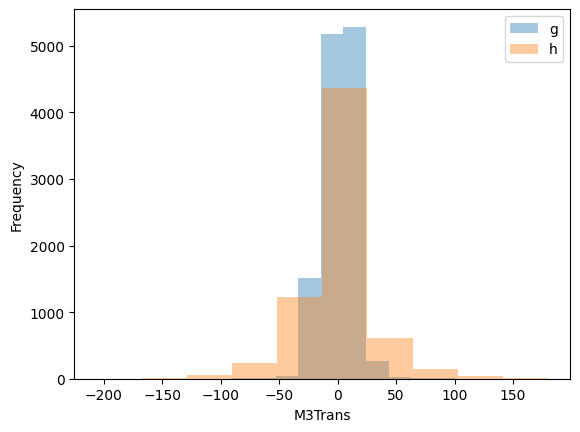

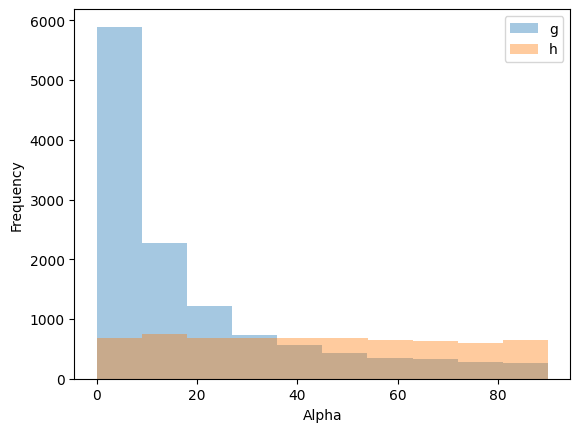

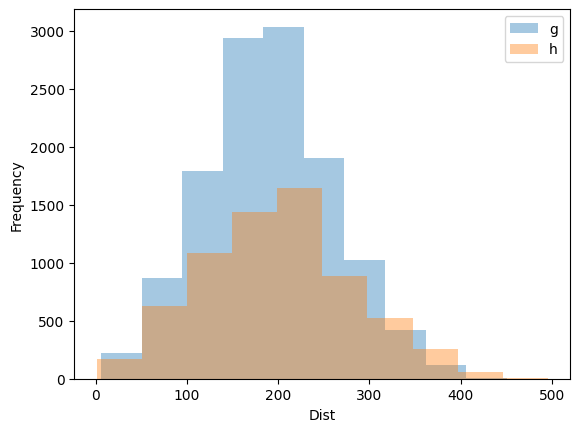

In [45]:
magic_class = magic.groupby("class")
for variable in magic.columns[:-1]:
    magic_class[variable].plot.hist(alpha=0.4, legend=True,xlabel=variable)
    plt.show()

Which combinations of variables might be useful in distinguishing signal from background?

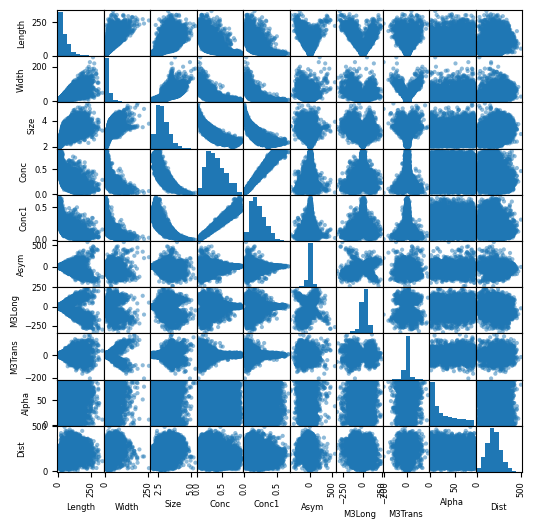

In [59]:
axs = pd.plotting.scatter_matrix(magic, figsize=(6, 6))
for ax in axs.flatten():
    ax.tick_params(labelsize=6)
    ax.xaxis.label.set_size(6)
    ax.yaxis.label.set_size(6)


plt.show()

### 1.3 Liver Cirrhosis

The file `data/cirrhosis.csv` contains data from a [study](https://archive.ics.uci.edu/dataset/878/cirrhosis+patient+survival+prediction+dataset-1) of liver cirrhosis patients.

The variable `Stage` characterises the stage of the disease.

Which observable variables are most useful for tracking the disease stage of a patient?